# **Task 1**

Path : 202618038_Lab_1\bookscraper\bookscraper\spiders\books_spider.py

# **Task 2**

### Importing Libraries

In [28]:
import pandas as pd
import numpy as np

### Loading Dataset

In [29]:
df = pd.read_csv("bookscraper/raw_books.csv")

df.head()

,title,category,price,rating,availability,description,upc,number_of_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,Two,In stock (19 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,Two,In stock (19 available) In stock In stock In s...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,One,In stock (19 available) In stock In stock In s...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,One,In stock (19 available) In stock In stock In s...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,Three,In stock (19 available) In stock In stock In s...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


### Total Records, Missing Values & Duplicate UPCs

In [30]:
print("Total Records :", len(df))

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate UPCs :", df["upc"].duplicated().sum())

Total Records : 100

Missing Values
title                0
category             0
price                0
rating               0
availability         0
description          0
upc                  0
number_of_reviews    0
product_url          0
dtype: int64

Duplicate UPCs : 0


### Clean Extra Spaces & Inconsistent Text

In [31]:
# Remove leading and trailing spaces
for col in ["title", "category", "availability", "description"]:
    df[col] = df[col].fillna("").str.strip()

# Remove multiple spaces
df["description"] = df["description"].str.replace(r"\s+", " ", regex=True)

### Remove Duplicate Books by UPC

In [32]:
df.drop_duplicates(subset="upc", inplace=True)

### Handle Missing Descriptions

In [33]:
df["description"] = df["description"].replace("", "No description available")

### Convert Price to Numeric

In [34]:
df["price"] = (
    df["price"]
    .str.replace("£", "", regex=False)
    .astype(float)
)

### Convert Ratings to Integers

In [35]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["rating"] = df["rating"].map(rating_map)

### Extract Available Stock Count

In [36]:
df["stock_count"] = (
    df["availability"]
    .str.extract(r"(\d+)")
    .astype(int)
)

### Features Extraction

In [37]:
df["description_word_count"] = (
    df["description"]
    .str.split()
    .str.len()
)

In [38]:
df["price_band"] = pd.cut(
    df["price"],
    bins=[0, 20, 40, 60],
    labels=["Low", "Medium", "High"]
)

In [39]:
df["recommended"] = np.where(
    (df["rating"] >= 4) & (df["price"] <= 30),
    "Yes",
    "No"
)

### Save Cleaned Dataset

In [40]:
df.to_csv("cleaned_books.csv", index=False)

df.head()

,title,category,price,rating,availability,description,upc,number_of_reviews,product_url,stock_count,description_word_count,price_band,recommended
0,It's Only the Himalayas,Travel,45.17,2,In stock (19 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...,19,230,High,No
1,Libertarianism for Beginners,Politics,51.33,2,In stock (19 available) In stock In stock In s...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...,19,195,High,No
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,37.59,1,In stock (19 available) In stock In stock In s...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...,19,283,Medium,No
3,Olio,Poetry,23.88,1,In stock (19 available) In stock In stock In s...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...,19,249,Medium,No
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,3,In stock (19 available) In stock In stock In s...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...,19,163,High,No


# **Task 3**

### Import Visualization Libraries

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

### Plot 1 - Price Distribution

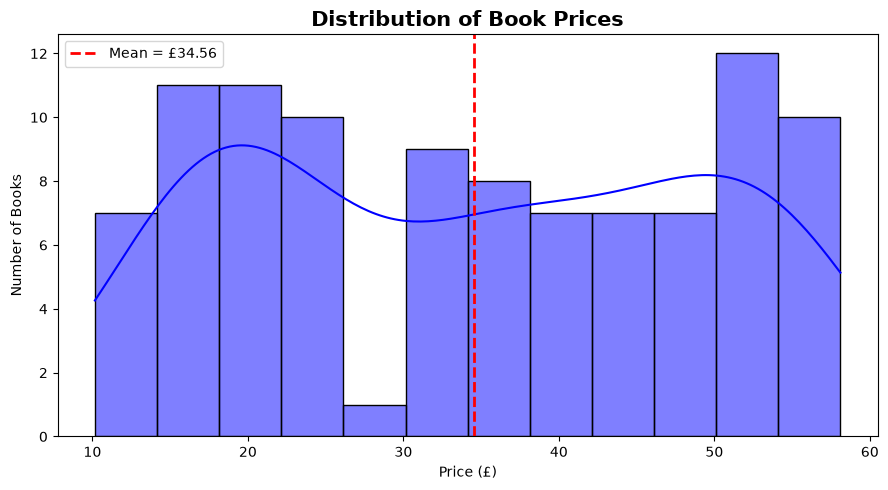

In [42]:
plt.figure(figsize=(9,5))

sns.histplot(
    df["price"],
    bins=12,
    kde=True,
    color="Blue",
    edgecolor="black"
)

plt.axvline(
    df["price"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = £{df['price'].mean():.2f}"
)

plt.title("Distribution of Book Prices", fontsize=15, weight="bold")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.legend()

plt.tight_layout()
plt.show()

### Plot 2 - Rating Distribution

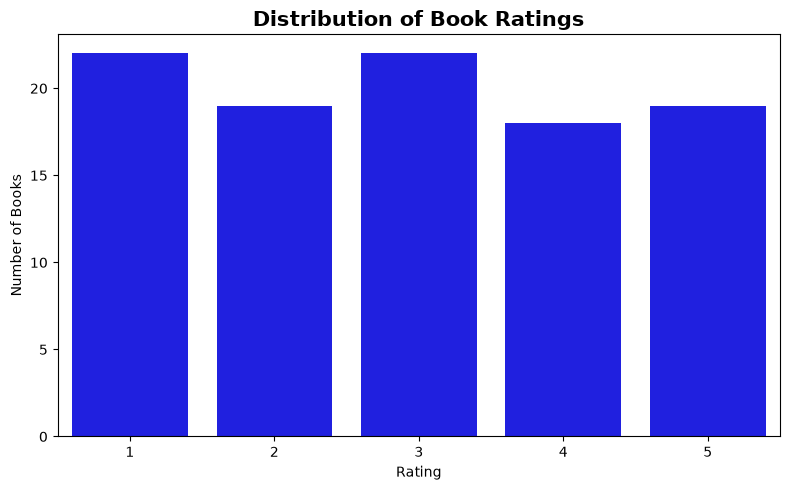

In [43]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="rating",
    color="Blue"
)

plt.title("Distribution of Book Ratings", fontsize=15, weight="bold")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.show()

### Plot 3 - Average Price by Category

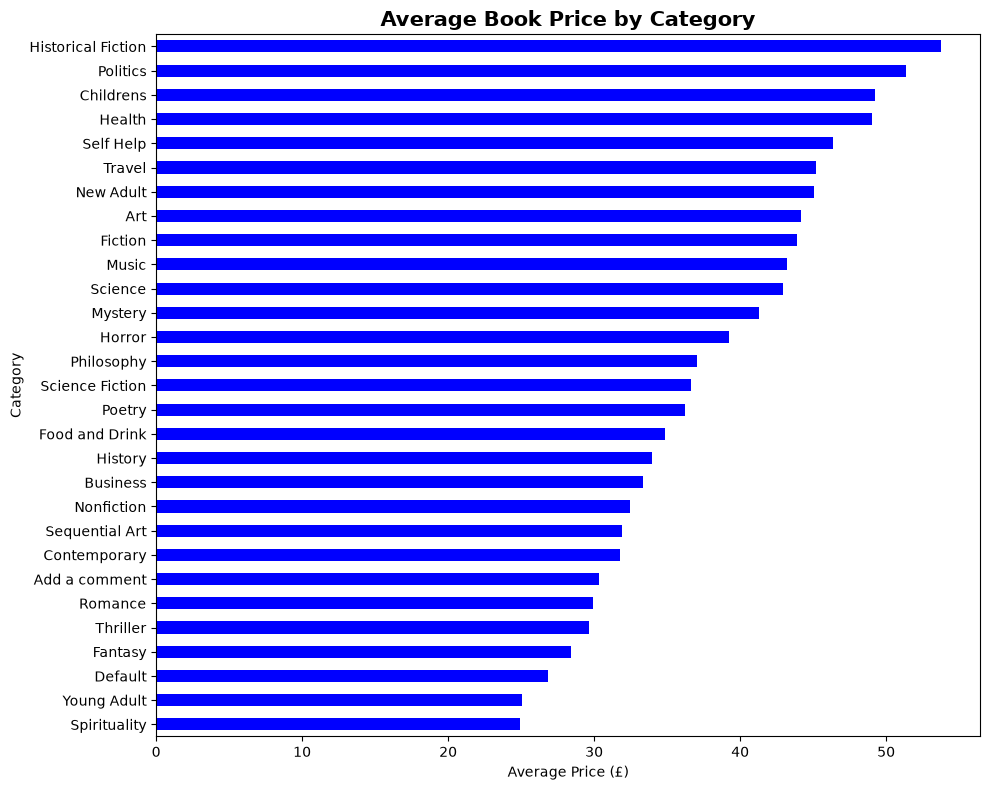

In [44]:
avg_price = (
    df.groupby("category")["price"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,8))

avg_price.plot(
    kind="barh",
    color="Blue"
)

plt.title("Average Book Price by Category", fontsize=15, weight="bold")
plt.xlabel("Average Price (£)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

### Plot 4 - Price vs Rating

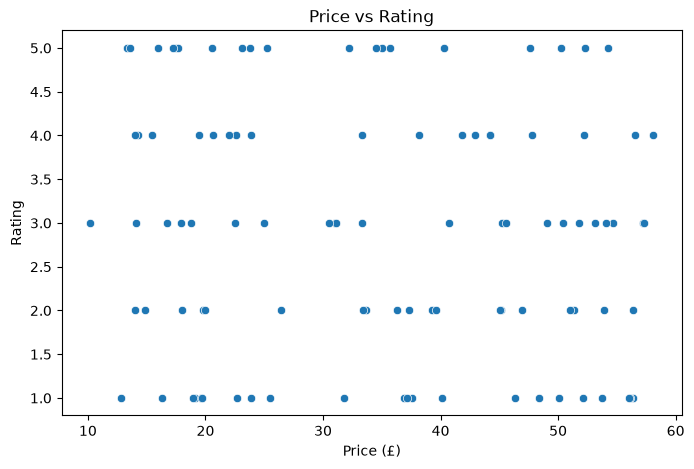

In [45]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="price",
    y="rating"
)

plt.title("Price vs Rating")
plt.xlabel("Price (£)")
plt.ylabel("Rating")

plt.show()

### Word Cloud

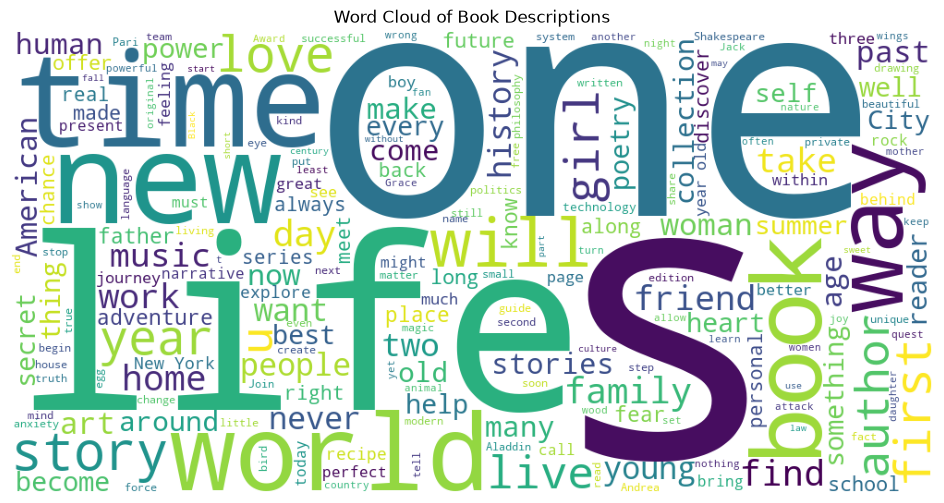

In [46]:
text = " ".join(df["description"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud of Book Descriptions")

plt.show()

### Summary Statistics

In [47]:
print(df.describe())

print("\nCategory Counts")
print(df["category"].value_counts())

print("\nAverage Price by Category")
print(df.groupby("category")["price"].mean())

print("\nAverage Rating by Category")
print(df.groupby("category")["rating"].mean())

print("\nAverage Stock by Category")
print(df.groupby("category")["stock_count"].mean())

            price      rating  number_of_reviews  stock_count  \
count  100.000000  100.000000              100.0   100.000000   
mean    34.560700    2.930000                0.0    17.180000   
std     14.638531    1.423149                0.0     1.479694   
min     10.160000    1.000000                0.0    16.000000   
25%     19.897500    2.000000                0.0    16.000000   
50%     34.775000    3.000000                0.0    16.000000   
75%     47.967500    4.000000                0.0    19.000000   
max     58.110000    5.000000                0.0    22.000000   

       description_word_count  
count              100.000000  
mean               224.710000  
std                107.798474  
min                 36.000000  
25%                163.750000  
50%                211.500000  
75%                276.500000  
max                722.000000  

Category Counts
category
Sequential Art        14
Nonfiction            12
Default                9
Poetry                 7


# **Task 4**

### Insights & Observations

1. Dataset has 100 books, with 0 missing values in any field and no duplicate UPCs.
2. Average book price is £34.56 and it ranges from £10.16 to £58.11. And the plot shows that most books are concentrated around the average price
3. Average rating is 2.93 out of 5, meaning 2 star and 3 star books are more common.
4. Sequential Art is the most represented category(contains 14 books), followed by nonfiction(12 books) and default(9 books).
5. Historical Fiction and Ploitics is the most expensive category on avearge.
6. Prices doesnt appear to have a strong relationship with rating.
7. Recommended books provide the best value because they combine high ratings with low prices.

### Conclusion

Book prices and ratings vary across categories with no strong relationship between price and rating. Also the category representation is uneven, and prices vary considerably across categories.

However, the analysis has some limitations. The dataset contains only 100 books so it doesnt represent the whole website.
Also all books have zero customer reviews, limiting review based analysis.